In [25]:
# import everything

%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import torch.nn.functional as F
from torch.optim import lr_scheduler as LR
from torch.utils.data import Dataset, DataLoader
import plotly.express as px
from functools import partial
from SimulateDatasets.ContrastiveGenerator import ContrastiveGenerator, AR1_ordered_data_gen, OrderedDataset, SampledDataset
from Network_models.CANTrainer import CANTrainer
from Network_models.PartitionedRNN import PartitionedNet
from utils.path_settings import *
import seaborn as sns
import os
from Rotations import integrate_velocities, exp_quat, q_mult, integrate_quat_sequential
from Plots.AttractorPlots import *
from Plots.globe_plots import *
import utils
import Operator.Operator as o
import copy
from Network_models.CTrainer_Pred_CAN import CTrainer_Pred_CAN
from SimulateDatasets.ContrastiveGenerator import ControlGenerator
from Operator.miscellaneous import *
from Network_models.GRUController import GRUControllerAlltogether
from SimulateDatasets.ContrastiveGenerator import ControlGenerator_GRU
from Network_models.CTrainer_GRU import CTrainer_GRU

# set up rep net
# adjustable knobs 
knobs = {
        "batch_size" : 4096,
        "mini_batch_size" : 256,
        "repUnits" : 128,
        "model" : "PartitionedRNN", # or "PartitionedCTRNN"
        # "model": "FlexibleRNN",
        "manifold" : "t", #"custom", # or "S"
        # "manifold" : "custom",
        "dim" : 1,
        "zeroNullRep" : False,
        "zeroNullInput" : False,
        "biasRep" : True,
        "biasInput" : True,
        "hihr_identity": False, 
        "cParam" : True,
        # "nonlinearity" : "tanh",
        "nonlinearity": "BiologicalReLU",
        # "nonlinearity": "BiologicalTanh",
        # "nonlinearity": "relu",
        # "nonlinearity": "NormedReLU", 
        "inputEnveloping" : False,
        "loss" : "infonce",
        "triplet_weight" : 0, # only turn if loss is triplet
        "normalize" : False,
        "similarity_kernel" : None,
        "weight_decay_thresh" : -10,
        "L2norm_scalar": 0,
        "manifold_name": "ModifiedRingManifold",
        # "similarity_kernel": "cosine", 
        "similarity_kernel": "euclidean",
        "capacity": False, 
        "manifold_params": {
            "R":1, 
            "A":0.2, 
            "n":5,
        },
        "temperature": 0.7, 
        "invariance_weight": 1,  
        # "bidirectional": False, 
        "epsilon_max":0.1,
    }
for key, value in knobs.items():
    exec(f"{key} = {f"{value}" if type(value) != str else f'"{value}"'}")
if knobs['hihr_identity'] == False:
    knobs['hihr_identity'] = None
if knobs["L2norm_scalar"] == 0:
    knobs["L2norm_scalar"] = None
if knobs["similarity_kernel"] == "cosine":
    knobs["similarity_kernel"] = None
exclude = ["batch_size", "mini_batch_size", "triplet_weight", "loss", "weight_decay_thresh"]
if knobs["manifold"].lower() in ["s", "t"]: 
    manifold_specs = {
        "manifold_path": "SimulateDatasets.Manifolds", 
        "manifold_name": "Sphere" if knobs["manifold"].lower() == "s" else "Torus",
        "manifold_params": {"dim": knobs["dim"], 
                            }
    }
    exclude.extend(["manifold_name", "manifold_params"])


if knobs["manifold"].lower() == "custom": 
    manifold_specs = {
        "manifold_path": "SimulateDatasets.Manifolds",
        "manifold_name": knobs["manifold_name"],
        "manifold_params": knobs["manifold_params"]
    }
configs, data_specs = utils.knobs2specs_CAN(knobs)

data_gen = ContrastiveGenerator(data_specs)

# or alternatively, define trainer and load a model
trainer = CANTrainer(configs)
path = utils.load_from_lookup(configs)
try: 
    trainer.load_model(path)
    print("Model loaded via train")
except Exception as e:
    print(e)    
    print("No model to load")
    trainer.load_model(configs["save_path"][:-9] + "best_model.pth")

rnn = trainer.model.to("cuda")
rnn.eval()
rnn.rnn.eval()
torch.save(rnn, path.replace("model.pth", "model_full.pth"))

class CosineActivation(nn.Module):
    def __init__(self, theta):
        super(CosineActivation, self).__init__()
        """theta is the angle of the cosine activation, 
        if it is a list, then output an expansive feature map
        """
        self.theta = theta

    def forward(self, x):
        if isinstance(self.theta, list):
            return torch.cat([torch.cos(x * theta) for theta in self.theta], dim=1)
        return torch.cos(x * self.theta)
class CosineSineActivation(nn.Module):
    def __init__(self, theta):
        super(CosineSineActivation, self).__init__()
        """theta is the angle of the cosine activation, 
        if it is a list, then output an expansive feature map
        """
        self.theta = theta

    def forward(self, x):
        if isinstance(self.theta, list):
            return torch.cat([torch.cos(x * theta) for theta in self.theta] + [torch.sin(x * theta) for theta in self.theta], dim=1)
        return torch.cat([torch.cos(x * self.theta), torch.sin(x * self.theta)], dim=1)
    
def expand_trig(theta):
    """
    theta: torch.tensor(batch_size, dim): thetas of different dimensions
    """
    return torch.cat([torch.cos(theta), torch.sin(theta)], dim=-1)

def pos2theta(y): 
    dim = y.shape[-1]//2
    theta = torch.zeros((*y.shape[:-1], dim))
    for i in range(dim):
        theta[..., i] = torch.atan2(y[..., i + dim], y[..., i])
    return theta

d = data_gen.generate_data(10, disregard_n_samples=False)
dpositions = d.positions.cpu().numpy()

rep_only = False
mapnet = nn.Sequential(
    # CosineActivation(theta=np.pi/2),
    # ArcCosineActivation(theta=np.pi/2),
    CosineSineActivation(theta=[0.5, 1, 2]),
    nn.Linear(dpositions.shape[1] * 6, 128), 
    nn.ReLU(),
    # CosineSineActivation(theta=[0.5, 1, 2]),
    # nn.Linear(128, 128),
    # nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, rnn.rnn.rep_units if rep_only else rnn.rnn.hidden_size),
    # nn.Linear(dpositions.shape[1], rnn.rnn.rep_units if rep_only else rnn.rnn.hidden_size),
    rnn.rnn.nonlinearity_fn if rnn.rnn.nonlinearity_fn is not torch.nn.functional.tanh else nn.Tanh(), 
)
readoutnet = nn.Sequential(
    nn.Linear(rnn.rnn.rep_units, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, dpositions.shape[1]) if dim != 1 else nn.Linear(128, dpositions.shape[1]*2),
)

mapnet = torch.load(path.replace("model.pth", "mapnet.pth"))
readoutnet = torch.load(path.replace("model.pth", "readoutnet.pth"))
from Operator.Operator import *
from Operator.miscellaneous import *


plt.rcParams['figure.titlesize'] = 18
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.handlelength'] = 1.5
plt.rcParams['legend.handleheight'] = 0.5
plt.rcParams['axes.spines.right'] = False
plt.rcParams[('axes.spines.top')] = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
input_connected: True
Using custom activation BiologicalReLU
1
no scheduler
Model loaded via train
torch.Size([10, 10, 1])
0.1


In [26]:
null_action = torch.ones(1, 16, dim).cuda() * 0.000
# null_action = torch.randn(1, 16, dim).cuda()
rnn.eval()
with torch.no_grad():
    final = rnn(null_action, truncate_output=False)
readoutnet = readoutnet.float()
y = readoutnet(final[:, :, -128:].float())
# y = y/torch.norm(y, dim=-1, keepdim=True)
pos2theta(y)

tensor([[[-0.0374],
         [ 0.0020],
         [ 0.0215],
         [ 0.0162],
         [ 0.0128],
         [ 0.0103],
         [ 0.0085],
         [ 0.0072],
         [ 0.0061],
         [ 0.0052],
         [ 0.0045],
         [ 0.0038],
         [ 0.0033],
         [ 0.0029],
         [ 0.0025],
         [ 0.0022],
         [ 0.0019]]], grad_fn=<CopySlices>)

In [27]:
model_type = 4

path_dicts = {
    1: {
        "it": 0, 
        "control_norm_weight": 0.3
    },
    2: {
        "it": 0,
        "control_norm_weight": 1.5
    },
    3: {
        "it": 2,
        "control_norm_weight": 3.1
    },
    4: {
        "it": 1,
        "control_norm_weight": 0.1
    }
}

conditions = {
    "full": {
        "recurrent_control": True,
        "hidden_control_dim": 128,
        "output_size": 32,
    },
    "no_recurrence": {
        "recurrent_control": False,
        "hidden_control_dim": 128,
        "output_size": 32,
    },
    "no_hidden": {
        "recurrent_control": True,
        "hidden_control_dim": 0,
        "output_size": 32,
    },
    "no_hidden_no_recurrence": {
        "recurrent_control": False,
        "hidden_control_dim": 0,
        "output_size": 32,
    },
    "no_hidden_no_recurrence_128": {
        "recurrent_control": False,
        "hidden_control_dim": 0,
        "output_size": 128,
    },
}

it = path_dicts[model_type]["it"]
condition = "no_hidden_no_recurrence" if model_type != 4 else "no_hidden_no_recurrence_128"
action_weight_, loss_traj_weight_, convergence_loss_weight_, control_norm_weight_ = 0.3, 0.3, 0.3, path_dicts[model_type]["control_norm_weight"]

weight_dict = {
    "action_weight": action_weight_,
    "loss_traj_weight": loss_traj_weight_,
    "convergence_loss_weight": convergence_loss_weight_,
    "control_norm_weight": control_norm_weight_
}
action_weight, loss_traj_weight, convergence_loss_weight, control_norm_weight = weight_dict.values()


In [28]:
from Operator.Operator import *
from Operator.miscellaneous import *

delay = 1
plant_state_size = 32
dt_plant = 0.1
action_modality = "velocity"
feedback_noise = 0.5
output_size = 32 if model_type != 4 else 128
action_size = 1 # from plant to operator
hidden_control_dim = 128
recurrent_control_dim = hidden_control_dim if hidden_control_dim > 0 else output_size
recurrent_control = False

modularized = True

try: 
    if output_size == 32:
        fly, plant = torch.load(MODEL_SAVE_PATH + "/LAL/fly32.pth"), torch.load(MODEL_SAVE_PATH + "/LAL/lal32.pth")
    else: 
        fly, plant = torch.load(MODEL_SAVE_PATH + "/LAL/fly128.pth"), torch.load(MODEL_SAVE_PATH + "/LAL/lal128.pth")
    fly.delay = delay
    fly.feedback_noise = feedback_noise
except:
    print ("No model to load")

    fly = Fly(
        {
            "device": "cuda", 
            "delay": delay,
            "plant_state_size": plant_state_size,
            "dt": dt_plant,
            "action_modality": action_modality,
            "feedback_noise": feedback_noise,
            "width": 0.1, # this is the widht o the 
        }
    )
    plant = LAL(controller_dim = output_size, n_lal_neurons=plant_state_size, use_dale = True, excitation_ratio = 0.8, init_scale = 0.7, dt = dt_plant)


if modularized:
    im1 = InternalModelMLP({
        "efference1": output_size, 
        "efference2": plant_state_size,
        "sensory": fly.state_size, 
        "can": rnn.rnn.rep_units 
    }, 
    [128], 
    action_size, 
    0, "relu", "linear", zero_initialization=False).cuda()

    use_rep, use_feedback = True, True
else:
    use_rep = False
    use_feedback = False
    im1_input_size = output_size + fly.state_size * use_feedback + rnn.rnn.rep_units * use_rep
    im1 = MLP(im1_input_size, 128, action_size, 0, "relu", "linear", zero_initialization=False).cuda()
# predictor = SingleLayerLM(rnn.rnn.hidden_size, wheel.position_size, 8).cuda()
predictor = MLP(rnn.rnn.hidden_size, 128, fly.position_size, 8, "relu", "tanh", zero_initialization=False, normalize=True).cuda()
fly.readout_matrix.weight.data = torch.cat([torch.ones_like(fly.readout_matrix.weight.data[:, :plant_state_size//2]), -torch.ones_like(fly.readout_matrix.weight.data[:, plant_state_size//2:])], dim=-1)
from copy import deepcopy
def trainer_factory(cond_params):
    # 1) Copy any modules so each trainer is independent
    plant_net = deepcopy(plant)
    operator  = deepcopy(fly)
    IM1_net   = deepcopy(im1)
    # predictor/readout
    predictor_copy = deepcopy(readoutnet)
    readout_net    = readoutnet

    # 2) Build the model_params, merging in cond_params
    hidden_dim = cond_params["hidden_control_dim"]
    model_params = {
        "rep_net": rnn,
        "plant": plant_net,
        "operator": operator,
        "IM1": IM1_net,
        "predictor": predictor_copy,
        "readoutnet": readout_net,
        "output_size":        cond_params["output_size"],
        "rep_units_only":     True,
        "recurrent_control":  cond_params["recurrent_control"],
        "activation":         "ReLU",
        "hidden_control_dim": hidden_dim,
        "recurrent_control_dim": hidden_dim if hidden_dim != 0 else cond_params["output_size"],
        "device":             "cuda",
        "use_rep":            use_rep,
        "use_feedback":       use_feedback,
    }

    model_specs = {
        "model_name":   "PredControlNetCAN_2",
        "model_path":   "Network_models.PIDController",
        "model_params": model_params,
    }

    optimizer_specs = {
        "compartmental_optimization": True,
        "optimizer_name":             "Adam",
        "optimizer_params":           {"lr": 0.003},
    }

    # 3) Put together the trainer config
    trainer_config = {
        "model_specs":              model_specs,
        "optimizer_specs":          optimizer_specs,
        "control_period":           20,
        "random_initial_condition": True,
        "additional_loss":          ["final_distance", "control_norm"],
        "save_path":           MODEL_SAVE_PATH + f"/Pred_Controller/Temp/", 
        "check_path":           MODEL_SAVE_PATH + f"/Pred_Controller/Temp/",
        "log_path":           LOG_PATH + f"/Pred_Controller/Temp/",
        # (you can add save_path/check_path/log_path here if needed)
    }

    # 4) Instantiate and return
    return CTrainer_Pred_CAN(trainer_config)



In [29]:
trainer = trainer_factory(conditions[condition])
output_size = conditions[condition]["output_size"]
hidden_control_dim = conditions[condition]["hidden_control_dim"]
recurrent_control = conditions[condition]["recurrent_control"]
path = MODEL_SAVE_PATH + f"/LAL/modularized_cp_{"single_sheet" if hidden_control_dim == 0 else "hidden" + str(hidden_control_dim)}_{output_size}_{loss_traj_weight}_{action_weight}_{convergence_loss_weight}_{control_norm_weight}_iteration{it}{"no_recurrence" if not recurrent_control else ""}.pth"
trainer.load_checkpoint(path)

Model loaded
no scheduler
['final_distance', 'control_norm']


In [30]:
W_pos = trainer.model.plant.apply_dale_constraint(trainer.model.plant.W_param.data).cpu().detach()
controller_signs = torch.sign(trainer.model.operator.readout_matrix.weight.cpu() @ W_pos.cpu())[0].cpu().numpy()

In [31]:
ctrl_pref = torch.load(f"{MODEL_SAVE_PATH}/LAL_ctrl_pref_type{model_type}")

In [35]:
def wrap(x): 
    return(x + np.pi) % (2 * np.pi) - np.pi

def qc_calc(q1, q2): 
    S       = ((q1 + q2 + np.pi) % (2*np.pi) - np.pi)/2 # ∈ [0,2π) 
    S_tilde = S - np.pi                            # ∈ [−π,+π)

    # Compute the “wrapped difference” between S_tilde and q1:
    diff_wrapped = wrap(S_tilde - q1)           # ∈ [−π,+π)
    mask         = (diff_wrapped.abs() < (np.pi / 2))  # boolean tensor (B,1)

    # Select: if mask[i] is True → S_tilde[i], else → S[i]
    q0 = torch.where(mask, S_tilde, S)
    return q0 
def dynamic_subsampling( q0, q1, tuning, threshold=np.pi):
    """
    Vectorized dynamic subsampling based on tuning map and input shifts.

    Args:
        q0: torch.Tensor (B, N), initial neural state
        q1: torch.Tensor (B, N), final neural state (unused in current logic)
        tuning: torch.Tensor (N, 2), tuning map [start, end] per neuron
        threshold: float, max allowed angular tuning span for inclusion
    """
    q1_expanded = q1.unsqueeze(2)  if q1.ndim == 2 else q1
    q0_expanded = q0.unsqueeze(2) 

    # qc = (q1_expanded + q0_expanded) % np.pi 
    qc = qc_calc(q1_expanded, q0_expanded)  +  np.pi
    # Compute wrapped tuning: (B, N, 2)
    wrapped_tuning = (tuning.unsqueeze(0) + qc) % (2 * np.pi) - qc
    wrapped_tuning2 = (tuning.unsqueeze(0) + qc) % (2 * np.pi) - qc
    # Compute tuning span: (B, N)
    diff = wrapped_tuning[:, :, 1] - wrapped_tuning[:, :, 0]
    diff2 = wrapped_tuning2[:, :, 1] + wrapped_tuning2[:, :, 0]

    # Binary mask: (B, N)
    tuning_masker = (diff.abs() < threshold).long() * (diff2.abs() < threshold).long()
    # tuning_masker = (diff.abs() < threshold).long()
    # Store for later use
    return tuning_masker, qc

def wrap(x: torch.Tensor) -> torch.Tensor:
    """
    Wrap an angle x (in radians) into [−π, +π).
    """
    return ((x + torch.pi) % (2 * torch.pi)) - torch.pi


def dynamic_subsampling(q0: torch.Tensor,
                        q1: torch.Tensor,
                        tuning: torch.Tensor,
                        threshold: float = np.pi):
    """
    Vectorized dynamic subsampling based on tuning map and input shifts.

    Args:
        q0: torch.Tensor of shape (B, N), initial neural state
        q1: torch.Tensor of shape (B, N), final neural state (unused below)
        tuning: torch.Tensor of shape (N, 2), tuning map [theta0, theta1] per neuron
        threshold: float, max allowed angular span for inclusion (here we use π)

    Returns:
        tuning_masker: torch.LongTensor of shape (B, N), where 1 means “keep” and 0 means “discard”
        qc:           torch.Tensor of shape (B, N, 1), equal to qc_calc(q1, q0) + π
    """
    # ----------------------------------------------------
    # 1) Compute qc (centre‐of‐rotation) and add π, then keep a singleton last dim
    q1_expanded = q1.unsqueeze(2) if q1.ndim == 2 else q1   # ensure shape (B, N, 1)
    q0_expanded = q0.unsqueeze(2)                           # shape (B, N, 1)

    qc = qc_calc(q1_expanded, q0_expanded) + np.pi          # shape (B, N, 1)
    # qc is now the “new zero” around which we wrap.

    # ----------------------------------------------------
    # 2) Extract each neuron’s θ₀, θ₁ from `tuning`, then subtract qc and wrap into [−π,+π).
    #
    #    tuning has shape (N,2), where tuning[:,0]=θ₀ and tuning[:,1]=θ₁ for each neuron.
    #    We want t0 = wrap( θ₀ − center ), t1 = wrap( θ₁ − center ), with center = qc.
    #
    #    - tuning0: shape (N,)
    #    - tuning1: shape (N,)
    #    We broadcast these to shape (B, N, 1) by doing `[None,:,None]`.
    tuning0 = tuning[:, 0]                    # (N,)
    tuning1 = tuning[:, 1]                    # (N,)

    # Shape (1, N, 1)  minus  (B, N, 1)  → broadcast to (B, N, 1)
    t0 = wrap(tuning0[None, :, None] - qc)    # (B, N, 1)
    t1 = wrap(tuning1[None, :, None] - qc)    # (B, N, 1)

    # ----------------------------------------------------
    # 3) Form s = t0 + t1,  d = t0 - t1. Both are shape (B, N, 1).
    s = t0 + t1       # shape (B, N, 1)
    d = t0 - t1       # shape (B, N, 1)

    # 4) The “middle square” condition is |s| ≤ π  and  |d| ≤ π.
    mask = (s.abs() <= torch.pi) & (d.abs() <= torch.pi)  # shape (B, N, 1), boolean

    # 5) Convert to long and squeeze off the last dimension → shape (B, N)
    tuning_masker = 1-mask.squeeze(-1).long()

    return tuning_masker, qc

trials = 4096
q0 = torch.linspace(0, 2 * np.pi, round(trials ** 0.5)).float().cuda().reshape(-1, 1)
q1 = torch.linspace(0, 2 * np.pi, round(trials ** 0.5)).float().cuda().reshape(-1, 1)
q0, q1 = torch.meshgrid(q0.squeeze(), q1.squeeze(), indexing='ij')
q0 = q0.reshape(-1, 1).cuda().float()
q1 = q1.reshape(-1,1, 1).cuda().float()

mask, qc = dynamic_subsampling(q0, q1, ctrl_pref.cuda(), threshold = 1 * np.pi)



In [68]:
item = 3119-64
print(q0[item], q1[item], qc[item])

tensor([-1.5957], device='cuda:0') tensor([[-1.5957]], device='cuda:0') tensor([[1.5459]], device='cuda:0')


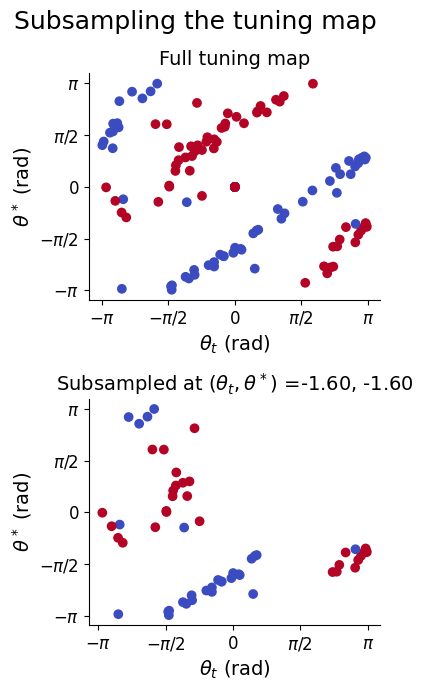

In [69]:
fig, ax = plt.subplots(2, 1, figsize = (4, 7))
ctrl_pref = (ctrl_pref+ np.pi) % (2 * np.pi) - np.pi  # Ensure tuning map is within [0, 2π]
ax[0].scatter(ctrl_pref.detach()[:, 0], ctrl_pref.detach()[:, 1], c = (controller_signs + 1)/2, cmap='coolwarm')
item =3119-64 
ctrl_sub = ctrl_pref[mask[item].bool().cpu()].detach()
sub_signs = controller_signs[mask[item].bool().cpu()]
ax[1].scatter(ctrl_sub[:, 0].cpu().numpy(), ctrl_sub[:, 1].cpu().numpy(), c = (sub_signs + 1)/2, cmap = 'coolwarm')
ax[0].set_title("Full tuning map")
ax[0].set_xlabel(r"$\theta_t$ (rad)")
ax[0].set_ylabel(r"$\theta^*$ (rad)")
ax[0].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax[0].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax[1].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax[1].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax[0].set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
ax[0].set_yticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
ax[1].set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
ax[1].set_yticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
ax[1].set_title("Full tuning map")
ax[1].set_xlabel(r"$\theta_t$ (rad)")
ax[1].set_ylabel(r"$\theta^*$ (rad)")
ax[1].set_title(rf"Subsampled at $(\theta_t, \theta^*)$ ={q0[item].item():.2f}, {q1[item].item():.2f}")
plt.suptitle(f"Subsampling the tuning map")
plt.tight_layout()
# fig.savefig(FIG_PATH + f"/LALsubsampling_tuning_map_{model_type}.png", bbox_inches='tight')
fig.savefig(FIG_PATH + f"/LALsubsampling_tuning_map_{model_type}_subat05pi.png", bbox_inches='tight')

In [171]:
(-np.pi/3 + np.pi) % (2 * np.pi) - np.pi

-1.0471975511965974

In [223]:
qc[2048]

tensor([[1.5957]], device='cuda:0')

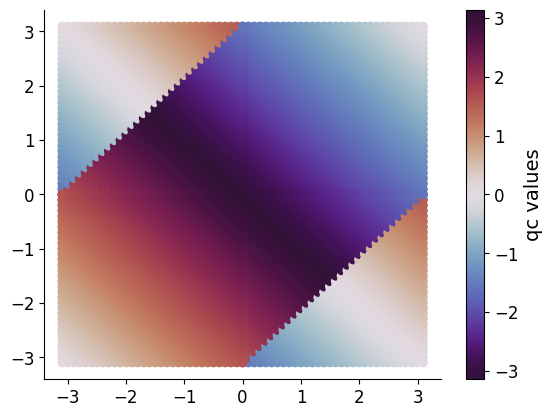

In [44]:
q0 = wrap(q0)
q1 = wrap(q1)

plt.scatter(q0.cpu().detach().numpy(), q1.cpu().detach().numpy(), c = (qc.cpu().detach().numpy() + np.pi) % (2 * np.pi) - np.pi , cmap='twilight_shifted')
plt.colorbar(label='qc values')
plt.savefig(FIG_PATH + f"/LALsubsampling_qc.png", bbox_inches='tight')


In [119]:
def wrap(x): 
    return(x + np.pi) % (2 * np.pi) - np.pi


def qc(q1, q2): 
    S       = (q1 + q2 + np.pi) % (2*np.pi)   # ∈ [0,2π) 
    S_tilde = S - np.pi                            # ∈ [−π,+π)

    # Compute the “wrapped difference” between S_tilde and q1:
    diff_wrapped = wrap(S_tilde - q1)           # ∈ [−π,+π)
    mask         = (diff_wrapped.abs() < (np.pi / 2))  # boolean tensor (B,1)

    # Select: if mask[i] is True → S_tilde[i], else → S[i]
    q0 = torch.where(mask, S_tilde, S)
    return q0 

In [122]:
qc(torch.tensor([0]), torch.tensor([0]))

tensor([0.])

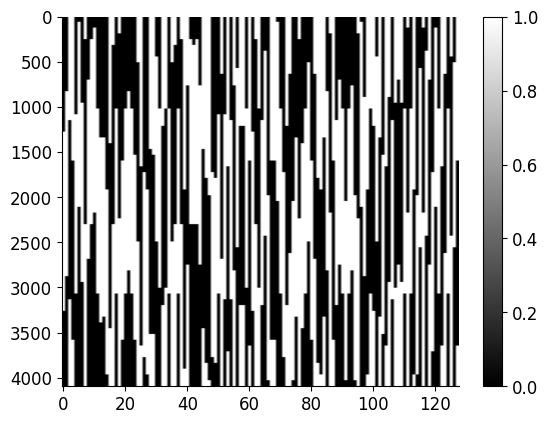

In [14]:
plt.imshow(mask.cpu().numpy(), aspect='auto', cmap='gray')
plt.colorbar()

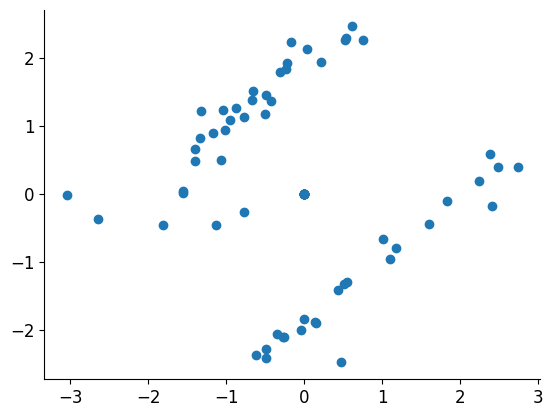

In [46]:
item = 0
ctrl_sub = ctrl_pref[mask[item].bool().cpu()].detach()
plt.scatter(ctrl_sub[:, 0].cpu().numpy(), ctrl_sub[:, 1].cpu().numpy())

In [20]:
inspect=False
use_s0 = False

trials=4096
test = "num_targets"  # "disturbance", "actuation_noise", "feedback_noise", "num_targets"
value = 0 

trainer.model.remove_disturbance()
if test == "disturbance":
    trainer.model.introduce_disturbance(scale=value, index=10)
if test == "actuation_noise": 
    old_value = trainer.model.operator.actuation_noise
    trainer.model.operator.actuation_noise = value
if test == "feedback_noise":
    old_value = trainer.model.operator.feedback_noise
    trainer.model.operator.feedback_noise = value
if test == "num_targets":
    targets = int(value)

q0 = torch.linspace(0, 2 * np.pi, round(trials ** 0.5)).float().cuda().reshape(-1, 1)
q1 = torch.linspace(0, 2 * np.pi, round(trials ** 0.5)).float().cuda().reshape(-1, 1)
q0, q1 = torch.meshgrid(q0.squeeze(), q1.squeeze(), indexing='ij')

q0 = q0.reshape(-1, 1).cuda().float()
q1 = q1.reshape(-1,1, 1).cuda().float()

trainer.model.dynamic_subsampling(q0, q1, ctrl_pref.cuda(), threshold = np.pi)

init = mapnet(q0)

final_ = mapnet(q1.view(-1, 1))[..., -128:].reshape(trials, 1, -1).float()

if use_s0:
   init =final[0, -1, :].expand(trials, -1)

# 
trainer.model.dynamic_sampling_on()
# trainer.model.dynamic_sampling_off()


# trainer.model.disactivate_controller(scale = 0.5)
trainer.model.activate_controller()
# trainer.model.remove_disturbance()
# trainer.model.reinitialize_controller()
with torch.no_grad():
    returned, network_activity = trainer.model.forward_return_hidden(init, final_, 20, inspect=inspect, use_s0 = use_s0, s0 = expand_trig(q0), observe = 10, include = {"im1": ["hidden", "output"],
                                                                                                                                                                       "controller": ["hidden", "output"], 
                                                                                                                                                                       "rep_net": ["input", "rep"]})
if test == "actuation_noise":
    trainer.model.operator.actuation_noise = old_value
elif test == "feedback_noise":
    trainer.model.operator.feedback_noise = old_value
elif test == "num_targets":
    trainer.model.N_targets = 1
elif test == "disturbance":
    trainer.model.remove_disturbance()
trainer.model.dynamic_sampling_off()

Subsampling is ON
Subsampling is OFF


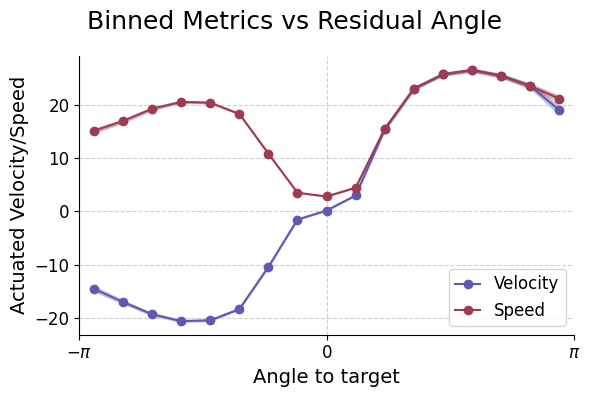

In [14]:
operatorpos = returned[-5]
velocities = operatorpos[:, 1:, -2]

theta1 = pos2theta(operatorpos[:, :-1, :2]).reshape(-1, 1) % (np.pi * 2)
target = q1.unsqueeze(2).expand(-1, -1, velocities.shape[1]//q1.shape[1], -1).contiguous().view(-1, 1)

# dist2targ = abs((target.cpu() - theta1 + np.pi) %(np.pi * 2) - np.pi)
dist2targ = (target.cpu() - theta1 ) %(np.pi * 2)
dist2targ = (dist2targ + np.pi) % (2 * np.pi) - np.pi
utils.plot_binned_metric_by_angle(dist2targ, velocities, n_bins = 17, plot_speed= True, plot_velocity=True, shade_stds = True,
                                  save = False, show = False, model_name = None, 
                                  xlab = "Angle to target", ylab = "Actuated Velocity/Speed",)
# plt.savefig(f"{FIG_PATH}/LAL_behavior_realized_velocity_128_relu_single_layer.png")
# plt.savefig(f"{FIG_PATH}/LAL_behavior_realized_velocity_{output_size}_relu_control_weight_action_weight{action_weight}{"single_layer" if hidden_control_dim == 0 else ""}{"no_recurrence" if not recurrent_control else ""}_iteration{it}.png")
plt.savefig(f"{FIG_PATH}/realized_velocity_after_adjustment_.png")
#

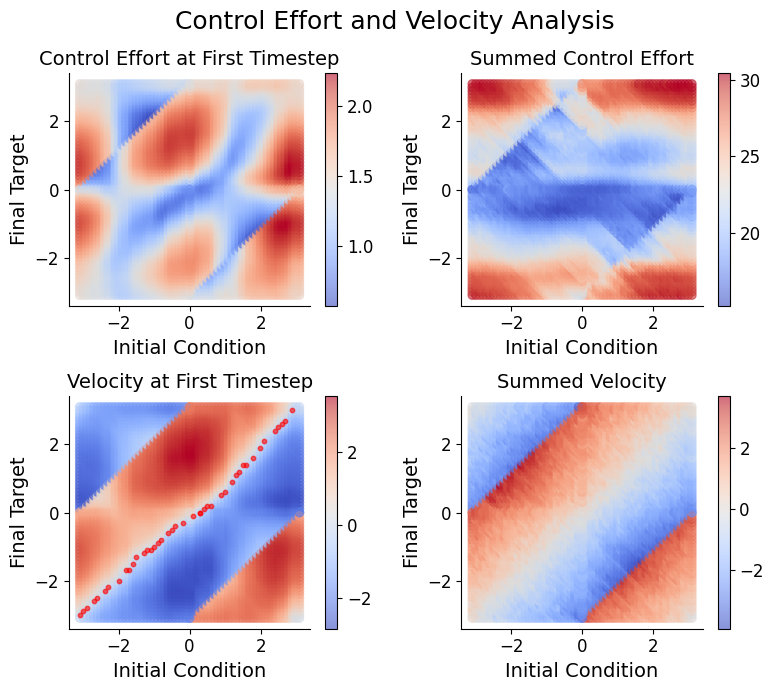

In [22]:
q0 = (q0 + np.pi) % (2 * np.pi) - np.pi
q1 = (q1 + np.pi) % (2 * np.pi) - np.pi
control_effort = returned[1]
velocity_effected = returned[-1]

fig, axs = plt.subplots(2, 2, figsize=(8, 7))

# First plot: Effort in the first timestep
effort_first_timestep = control_effort[:, 0, :].norm(dim=-1).cpu().detach().numpy()
sc = axs[0, 0].scatter(q0.cpu().numpy(), q1[:, 0].cpu().numpy(), c=effort_first_timestep, cmap='coolwarm', alpha=0.6)
axs[0, 0].set_title("Control Effort at First Timestep")
axs[0, 0].set_xlabel("Initial Condition")
axs[0, 0].set_ylabel("Final Target")
plt.colorbar(sc, ax=axs[0, 0])

# Second plot: Summed Effort
summed_effort = control_effort.norm(dim=-1).sum(dim=1).cpu().detach().numpy()
sc = axs[0, 1].scatter(q0.cpu().numpy(), q1[:, 0].cpu().numpy(), c=summed_effort, cmap='coolwarm', alpha=0.6)
axs[0, 1].set_title("Summed Control Effort")
axs[0, 1].set_xlabel("Initial Condition")
axs[0, 1].set_ylabel("Final Target")
plt.colorbar(sc, ax=axs[0, 1])

# Third plot: Velocity at First Timestep
velocity_first_timestep = velocity_effected[:, 0].cpu().detach().numpy()
sc = axs[1, 0].scatter(q0.cpu().numpy(), q1[:, 0].cpu().numpy(), c=velocity_first_timestep, cmap='coolwarm', alpha=0.6)
axs[1, 0].set_title("Velocity at First Timestep")
axs[1, 0].set_xlabel("Initial Condition")
axs[1, 0].set_ylabel("Final Target")
plt.colorbar(sc, ax=axs[1, 0])

# Highlight very small velocities
small_velocity_mask = np.abs(velocity_first_timestep) < 0.1
axs[1, 0].scatter(q0.cpu().numpy()[small_velocity_mask], q1[:, 0].cpu().numpy()[small_velocity_mask], color='red', s=10, alpha=0.6)

# Fourth plot: Summed Velocity
summed_velocity = velocity_effected.sum(dim=1).cpu().detach().numpy() * 0.2
sc = axs[1, 1].scatter(q0.cpu().numpy(), q1[:, 0].cpu().numpy(), c=summed_velocity, cmap='coolwarm', alpha=0.6)
axs[1, 1].set_title("Summed Velocity")
axs[1, 1].set_xlabel("Initial Condition")
axs[1, 1].set_ylabel("Final Target")
plt.colorbar(sc, ax=axs[1, 1])

# Highlight very small velocities
# small_velocity_mask = np.abs(summed_velocity) <1 
# axs[1, 1].scatter(q0.cpu().numpy()[small_velocity_mask], q1[:, 0].cpu().numpy()[small_velocity_mask], color='red', s=10, alpha=0.6)

# inferred_velocity = returned[-4]
# # Fifth plot: Inferred Velocity at First Timestep
# inferred_velocity_first_timestep = inferred_velocity[:, 0].cpu().detach().numpy()
# sc = axs[2, 0].scatter(q0.cpu().numpy(), q1[:, 0].cpu().numpy(), c=inferred_velocity_first_timestep, cmap='coolwarm', alpha=0.6)
# axs[2, 0].set_title("Inferred Velocity at First Timestep")
# axs[2, 0].set_xlabel("Initial Condition")
# axs[2, 0].set_ylabel("Final Target")
# plt.colorbar(sc, ax=axs[2, 0])

# # Highlight very small velocities
# small_velocity_mask = np.abs(inferred_velocity_first_timestep) < 0.01
# axs[2, 0].scatter(q0.cpu().numpy()[small_velocity_mask], q1[:, 0].cpu().numpy()[small_velocity_mask], color='red', s=10, alpha=0.6)

# # Sixth plot: Summed Inferred Velocity
# summed_inferred_velocity = inferred_velocity.sum(dim=1).cpu().detach().numpy()
# sc = axs[2, 1].scatter(q0.cpu().numpy(), q1[:, 0].cpu().numpy(), c=summed_inferred_velocity, cmap='coolwarm', alpha=0.6)
# axs[2, 1].set_title("Summed Inferred Velocity")
# axs[2, 1].set_xlabel("Initial Condition")
# axs[2, 1].set_ylabel("Final Target")
# plt.colorbar(sc, ax=axs[2, 1])

# Highlight very small velocities
# small_velocity_mask = np.abs(summed_inferred_velocity) < 0.1
# axs[2, 1].scatter(q0.cpu().numpy()[small_velocity_mask], q1[:, 0].cpu().numpy()[small_velocity_mask], color='red', s=10, alpha=0.6)

plt.suptitle("Control Effort and Velocity Analysis")
plt.tight_layout()
plt.savefig(f"{FIG_PATH}/LAL_behavior_control_effort_velocity_{output_size}_relu_control_weight_action_weight{action_weight}{"single_layer" if hidden_control_dim == 0 else ""}{"no_recurrence" if not recurrent_control else ""}_iteration{it}_adjusted.png")
plt.show()


In [153]:
v_full, effort_full = torch.load(f"{MODEL_SAVE_PATH}/LAL_velocity_effort_type4.pth")

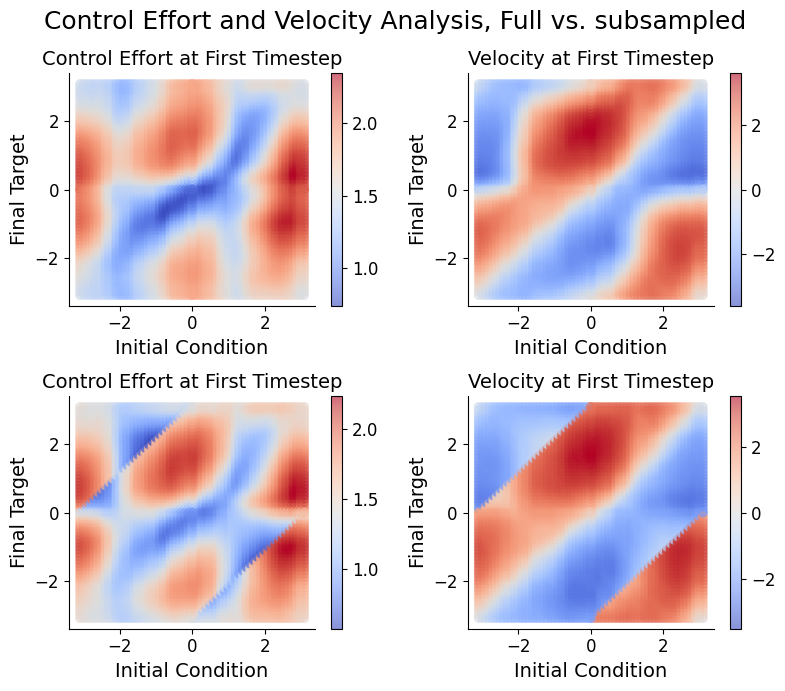

In [237]:
q0 = (q0 + np.pi) % (2 * np.pi) - np.pi
q1 = (q1 + np.pi) % (2 * np.pi) - np.pi
control_effort = returned[1]
velocity_effected = returned[-1]

fig, axs = plt.subplots(2, 2, figsize=(8, 7))

# First plot: Effort in the first timestep
sc = axs[0, 0].scatter(q0.cpu().numpy(), q1[:, 0].cpu().numpy(), c=effort_full, cmap='coolwarm', alpha=0.6)
axs[0, 0].set_title("Control Effort at First Timestep")
axs[0, 0].set_xlabel("Initial Condition")
axs[0, 0].set_ylabel("Final Target")
plt.colorbar(sc, ax=axs[0, 0])


# Third plot: Velocity at First Timestep
norm = plt.Normalize(vmin=-max(abs(v_full.min()), abs(v_full.max())), vmax=max(abs(v_full.min()), abs(v_full.max())))
sc = axs[0, 1].scatter(q0.cpu().numpy(), q1[:, 0].cpu().numpy(), c=v_full, cmap='coolwarm', alpha=0.6, norm = norm)
axs[0, 1].set_title("Velocity at First Timestep")
axs[0, 1].set_xlabel("Initial Condition")
axs[0, 1].set_ylabel("Final Target")
plt.colorbar(sc, ax=axs[0, 1])


# First plot: Effort in the first timestep
effort_first_timestep = control_effort[:, 0, :].norm(dim=-1).cpu().detach().numpy()
sc = axs[1, 0].scatter(q0.cpu().numpy(), q1[:, 0].cpu().numpy(), c=effort_first_timestep, cmap='coolwarm', alpha=0.6)
axs[1, 0].set_title("Control Effort at First Timestep")
axs[1, 0].set_xlabel("Initial Condition")
axs[1, 0].set_ylabel("Final Target")
plt.colorbar(sc, ax=axs[1, 0])


# Third plot: Velocity at First Timestep
velocity_first_timestep = velocity_effected[:, 0].cpu().detach().numpy()
norm = plt.Normalize(vmin=-max(abs(velocity_first_timestep.min()), abs(velocity_first_timestep.max())), vmax=max(abs(velocity_first_timestep.min()), abs(velocity_first_timestep.max())))
sc = axs[1, 1].scatter(q0.cpu().numpy(), q1[:, 0].cpu().numpy(), c=velocity_first_timestep, cmap='coolwarm', alpha=0.6, norm = norm)
axs[1, 1].set_title("Velocity at First Timestep")
axs[1, 1].set_xlabel("Initial Condition")
axs[1, 1].set_ylabel("Final Target")
plt.colorbar(sc, ax=axs[1, 1])

plt.suptitle("Control Effort and Velocity Analysis, Full vs. subsampled")
plt.tight_layout()
# plt.savefig(f"{FIG_PATH}/LAL_behavior_control_effort_velocity_{output_size}_relu_control_weight_action_weight{action_weight}{"single_layer" if hidden_control_dim == 0 else ""}{"no_recurrence" if not recurrent_control else ""}_iteration{it}.png")
plt.savefig(f"{FIG_PATH}/dynamic_sampling_full_vs_subsampled.png")
plt.show()



In [16]:
trainer.model.operator.dt

0.02